# Data Visualization for Actuaries
## A 90-Minute Practical Workshop

**Welcome!** In this session, we will explore essential data manipulation and visualization techniques using Python. You will learn to work with NumPy arrays, manipulate data with Pandas, and create compelling visualizations using Pandas and Seaborn.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ktnspr/py4ac/blob/main/04_data_visualization.ipynb) [![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ktnspr/py4ac/blob/main/04_data_visualization.ipynb)

### Session Overview
- **Part 1**: NumPy Basics — Arrays, indexing, and vectorized operations
- **Part 2**: Pandas Basics — DataFrames, data exploration, and aggregation
- **Part 3**: Plotting with Pandas — Creating informative visualizations
- **Part 4**: Advanced Visualization — Seaborn distributions and pairplots

*Duration*: 90 minutes  
*Audience*: Actuaries and quantitative professionals  
*Prerequisites*: Basic Python knowledge

In [1]:
# Colab setup: fetch helper module if running in Google Colab
import sys
if "google.colab" in sys.modules:
    !wget -qN https://raw.githubusercontent.com/ktnspr/py4ac/main/mytools.py

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mytools import generate_sample_insurance_data

# Set visualization defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Avoid truncation of DataFrame output in Jupyter
pd.set_option('display.expand_frame_repr', False)

# Display all columns in the DataFrame output
pd.set_option('display.max_columns', None)

# Define a separator for better readability
sep = "=" * 50


## Part 1: NumPy Basics

NumPy is the foundation of numerical computing in Python. It provides efficient arrays and vectorized operations that are essential for data analysis and scientific computing.

### 1.1 Creating Arrays from Nested Lists

You can create NumPy arrays from Python lists. NumPy arrays can be multi-dimensional:

| Dimension | Example | Description |
|-----------|---------|-------------|
| 1D | `np.array([1, 2, 3])` | A single row or column |
| 2D | `np.array([[1, 2], [3, 4]])` | A matrix with rows and columns |
| 3D+ | Higher-dimensional structures | For complex data |

**Key advantages of NumPy arrays:**
- Efficient memory usage
- Fast vectorized operations
- Broadcasting across different array shapes
- Seamless integration with other libraries

### Example: Insurance Premium Calculation
Suppose you have an array of base premiums and want to apply a 10% loading. With NumPy:

$$\text{Loaded Premium} = \text{Base Premium} \times 1.10$$

In [3]:
# Create and manipulate NumPy arrays
base_premiums = np.array([500, 750, 1000, 1200, 950])

# Apply a 10% loading
loaded_premiums = base_premiums * 1.10

# Base Premiums
print(f"\n{sep}\nBase Premiums: base_premiums\n{sep}")
print(base_premiums)

# Loaded Premiums
print(f"\n{sep}\nLoaded Premiums: base_premiums * 1.10\n{sep}")
print(loaded_premiums)


Base Premiums: base_premiums
[ 500  750 1000 1200  950]

Loaded Premiums: base_premiums * 1.10
[ 550.  825. 1100. 1320. 1045.]


Next, let's create a 2D array (matrix) to store premium data for multiple policyholders, with columns for base premium, loading, and final premium.

In [4]:
# Create a 2D array (matrix) of premium data
# Rows: policyholders, Columns: base, loading, final
premium_data = np.array([
    [500, 50, 550],
    [750, 75, 825],
    [1000, 100, 1100],
    [1200, 120, 1320],
    [950, 95, 1045]
])

# Premium Data (2D Array)
print(f"\n{sep}\nPremium Data (2D Array): Rows=Policyholders, Cols=Types\n{sep}")
print(premium_data)



Premium Data (2D Array): Rows=Policyholders, Cols=Types
[[ 500   50  550]
 [ 750   75  825]
 [1000  100 1100]
 [1200  120 1320]
 [ 950   95 1045]]


### 1.2 Array Indexing and Slicing

Once you have an array, you can access elements in multiple ways:

```python
arr = np.array([10, 20, 30, 40, 50])
arr[0]        # First element: 10
arr[-1]       # Last element: 50
arr[1:4]      # Elements from index 1 to 3: [20, 30, 40]
arr[::2]      # Every second element: [10, 30, 50]
```

For 2D arrays, you use `arr[row, column]` or `arr[row][column]`.

In [ ]:
# Premium Data (2D Array) Overview
print(f"\n{sep}\nPremium Data: Rows=Policyholders, Cols=Types\n{sep}")
print(premium_data)

# Access Individual Element (Row 0, Col 2)
print(f"\n{sep}\nFirst Policyholder's Final Premium: premium_data[0, 2]\n{sep}")
print(premium_data[0, 2])

# Access Column (All Final Premiums)
print(f"\n{sep}\nAll Final Premiums: premium_data[:, 2]\n{sep}")
print(premium_data[:, 2])

# Access Row (First Policyholder's Data)
print(f"\n{sep}\nFirst Policyholder's Data: premium_data[0, :]\n{sep}")
print(premium_data[0, :])


Premium Data: Rows=Policyholders, Cols=Types
[[ 500   50  550]
 [ 750   75  825]
 [1000  100 1100]
 [1200  120 1320]
 [ 950   95 1045]]

First Policyholder's Final Premium: premium_data[0, 2]
550

All Final Premiums: premium_data[:, 2]
[ 550  825 1100 1320 1045]

First Policyholder's Data: premium_data[0, :]
[500  50 550]


### 1.3 Universal Functions (ufuncs)

Universal functions perform element-wise operations on arrays. Common ufuncs include:

- `np.sqrt()` — Square root
- `np.exp()` — Exponential function
- `np.log()` — Natural logarithm
- `np.sin()`, `np.cos()` — Trigonometric functions
- `np.abs()` — Absolute value

These operations are **vectorized**, meaning they apply to all elements simultaneously without explicit loops. The exercise below demonstrates `np.log()` and `np.sqrt()` in practice.

## Part 2: Pandas Basics

Pandas is built on top of NumPy and provides the `Series` ="array/1D" and `DataFrame`="2D" objects. A DataFrame is like a spreadsheet with labeled columns and rows, making data manipulation intuitive.

### 2.1 Creating Series from Lists

A Series is a one-dimensional labeled array. You can create it from a list:

```python
age_series = pd.Series([28, 35, 42], name='age')
```

An integer index is automatically assigned, but you can specify a custom index if needed.

### 2.2 Creating DataFrames from Dictionaries (key:value, where value is a list)

You can combine multiple Series to form a DataFrame:

```python
df = pd.DataFrame({
    'age': [28, 35, 42],
    'premium': [500, 750, 1000],
    'region': ['North', 'South', 'East']
})
```

Or from a dictionary of Series, ensuring all have the same index.

### 2.3 Accessing Data

Pandas provides multiple ways to access data:

| Method | Purpose | Example |
|--------|---------|---------|
| `df[column]` | Access entire column | `df['age']` |
| `.loc[]` | Label-based access | `df.loc[0, 'age']` |
| `.iloc[]` | Position-based access | `df.iloc[0, 1]` |

In [6]:
# Load sample insurance data
df = generate_sample_insurance_data(n=100, seed=17)

# Preview -df.head()
print(f"\n{sep}\nData Preview (Head)\n{sep}\n{df.head()}")

# Accessing a Single Value (Age)
print(f"\n{sep}\nSingle Value Access\n{sep}")
print(f"By Label (.loc[0, 'age']):  {df.loc[0, 'age']}")
print(f"By Index (.iloc[0, 1]):    {df.iloc[0, 1]}")

# Column Access
print(f"\n{sep}\nColumn Access: df['age']\n{sep}\n{df['age'].head()}")

# Row Access
print(f"\n{sep}\nRow Access: df.loc[0, :]\n{sep}\n{df.loc[0, :]}")


Data Preview (Head)
   policyholder_id  age  gender   region vehicle_type  annual_premium  claims_count  claim_amount
0                1   65    Male    North    Mid-range          651.72             2        375.30
1                2   67  Female     West    Mid-range         1276.94             3       3284.18
2                3   33    Male  Central          SUV         1683.39             1        601.22
3                4   24    Male  Central       Luxury         1593.78             2       4193.67
4                5   40  Female     East          SUV         2436.14             1        680.04

Single Value Access
By Label (.loc[0, 'age']):  65
By Index (.iloc[0, 1]):    65

Column Access: df['age']
0    65
1    67
2    33
3    24
4    40
Name: age, dtype: int64

Row Access: df.loc[0, :]
policyholder_id            1
age                       65
gender                  Male
region                 North
vehicle_type       Mid-range
annual_premium        651.72
claims_count       

### 2.4 Data Exploration Methods

Pandas provides convenient methods for understanding your data:

```python
df.head()           # First 5 rows
df.tail()           # Last 5 rows
df.info()           # Data types and non-null counts
df.describe()       # Statistical summary
df.columns          # Column names
df.dtypes           # Data types
df.isna().sum()     # Count missing values per column
df['column'].unique()      # Unique values
df['column'].value_counts() # Value frequencies
```

In [7]:
# Dataset Information: df.info()
print(f"\n{sep}\nDataset Information: df.info()\n{sep}")
df.info()

# Statistical Summary: df.describe()
print(f"\n{sep}\nStatistical Summary: df.describe()\n{sep}")
print(df.describe())


Dataset Information: df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   policyholder_id  100 non-null    int64  
 1   age              100 non-null    int64  
 2   gender           100 non-null    object 
 3   region           100 non-null    object 
 4   vehicle_type     100 non-null    object 
 5   annual_premium   100 non-null    float64
 6   claims_count     100 non-null    int64  
 7   claim_amount     100 non-null    float64
dtypes: float64(2), int64(3), object(3)
memory usage: 6.4+ KB

Statistical Summary: df.describe()
       policyholder_id         age  annual_premium  claims_count  claim_amount
count       100.000000  100.000000      100.000000    100.000000    100.000000
mean         50.500000   48.220000     1719.237500      1.360000   1307.181700
std          29.011492   17.229045      885.117687      1.235175   232

In [8]:
# Column Names
print(f"\n{sep}\nColumn Names: df.columns.tolist()\n{sep}")
print(df.columns.tolist())

# Data Types
print(f"\n{sep}\nData Types: df.dtypes\n{sep}")
print(df.dtypes)

# Missing Values
print(f"\n{sep}\nMissing Values: df.isna().sum()\n{sep}")
print(df.isna().sum())



Column Names: df.columns.tolist()
['policyholder_id', 'age', 'gender', 'region', 'vehicle_type', 'annual_premium', 'claims_count', 'claim_amount']

Data Types: df.dtypes
policyholder_id      int64
age                  int64
gender              object
region              object
vehicle_type        object
annual_premium     float64
claims_count         int64
claim_amount       float64
dtype: object

Missing Values: df.isna().sum()
policyholder_id    0
age                0
gender             0
region             0
vehicle_type       0
annual_premium     0
claims_count       0
claim_amount       0
dtype: int64


Now let's inspect the categorical columns to understand the distinct values and their distributions.

In [9]:
# Unique Values: Region
print(f"\n{sep}\nUnique Regions: df['region'].unique()\n{sep}")
print(df['region'].unique())


# Unique Values: Vehicle Types
print(f"\n{sep}\nUnique Vehicle Types: df['vehicle_type'].unique()\n{sep}")
print(df['vehicle_type'].unique())


# Distribution: Gender
print(f"\n{sep}\nGender Distribution: df['gender'].value_counts()\n{sep}")
print(df['gender'].value_counts())



Unique Regions: df['region'].unique()
['North' 'West' 'Central' 'East' 'South']

Unique Vehicle Types: df['vehicle_type'].unique()
['Mid-range' 'SUV' 'Luxury' 'Compact']

Gender Distribution: df['gender'].value_counts()
gender
Female        48
Male          46
Non-binary     6
Name: count, dtype: int64


In [10]:
dir(df) #methods behind Pandas

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__arrow_c_stream__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__dataframe__',
 '__dataframe_consortium_standard__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pandas_priority__',
 '__pos__',
 '__pow__',
 '__r

### 2.5 Reading and Writing CSV Files

One of the most common tasks in data analysis is **reading data from files** and **writing results back**.
Pandas makes this remarkably straightforward with `to_csv()` and `read_csv()`.

| Method | Description | Example |
|--------|-------------|----------|
| `df.to_csv('file.csv', index=False)` | Write DataFrame to a CSV file | Export for sharing or archiving |
| `pd.read_csv('file.csv')` | Read a CSV file into a DataFrame | Load external data for analysis |

> **Tip:** Use `index=False` when writing to avoid saving the DataFrame index as an extra column.

In [14]:
# Write the insurance DataFrame to a CSV file
df.to_csv('insurance_sample.csv', index=False) #brez številk za vrstice
print('Data written to insurance_sample.csv')

# Read the CSV file back into a new DataFrame #možno, da ne bo ok, ko boš pisal/bral v csv, ker je drugačen format številk?? predavatelj ni prepričan :)
df_loaded = pd.read_csv('insurance_sample.csv')

# Verify that the loaded data matches the original
print(f'Original shape:  {df.shape}')
print(f'Loaded shape:    {df_loaded.shape}')
print(f'Data identical:  {df.equals(df_loaded)}')

df_loaded.head(3)

Data written to insurance_sample.csv
Original shape:  (100, 8)
Loaded shape:    (100, 8)
Data identical:  True


,policyholder_id,age,gender,region,vehicle_type,annual_premium,claims_count,claim_amount
0,1,65,Male,North,Mid-range,651.72,2,375.30
1,2,67,Female,West,Mid-range,1276.94,3,3284.18
2,3,33,Male,Central,SUV,1683.39,1,601.22


### 2.6 Grouping and Aggregation

A powerful feature for actuarial analysis is grouping:

```python
df.groupby('region')['premium'].mean()
```

This groups by region and calculates the mean premium per region. You can also aggregate with multiple functions or group by multiple columns.

### 2.7 *Reading Exercise: Pandas Data Exploration*

You will now explore an insurance dataset using Pandas methods. The data is generated with slightly different parameters than before. Explore the dataset by varying the following examples:

1. **Examine the dataset structure** using `.head()`, `.info()`, and `.describe()`
2. **Analyze categorical columns** using `.unique()` and `.value_counts()`
3. **Compute grouped aggregations**, e.g.:
   - Average premium by region
   - Average claims count by vehicle type
   - Count of policyholders by gender

**Instructions:**
- Read and understand the provided code cells below. You will find some new functions we haven't covered yet.
- Experiment with different grouping and aggregation combinations

In [18]:
# Load sample insurance data
df = generate_sample_insurance_data(n=300, seed=42)

# Column Names
print(f"\n{sep}\nColumn Names: df.columns.tolist()\n{sep}")
print(df.columns.tolist()) #zgleda boljše kot to spodaj
print(df.columns)



# Age Statistics: df['age'].describe()
print(f"\n{sep}\nAge Statistics: df['age'].describe()\n{sep}")
print(df['age'].describe())


# Premium Statistics: df['annual_premium'].describe()
print(f"\n{sep}\nPremium Statistics: df['annual_premium'].describe()\n{sep}")
print(df['annual_premium'].describe())



Column Names: df.columns.tolist()
['policyholder_id', 'age', 'gender', 'region', 'vehicle_type', 'annual_premium', 'claims_count', 'claim_amount']
Index(['policyholder_id', 'age', 'gender', 'region', 'vehicle_type',
       'annual_premium', 'claims_count', 'claim_amount'],
      dtype='object')

Age Statistics: df['age'].describe()
count    300.000000
mean      45.876667
std       16.870988
min       18.000000
25%       31.750000
50%       45.000000
75%       60.250000
max       75.000000
Name: age, dtype: float64

Premium Statistics: df['annual_premium'].describe()
count     300.000000
mean     1842.409800
std       869.436167
min       418.540000
25%      1227.600000
50%      1691.510000
75%      2323.035000
max      5013.770000
Name: annual_premium, dtype: float64


In [19]:
# Age Group Binning: pd.cut() - we haven't covered this yet, but it should be understandable ;-)
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 100], labels=['<30', '30-40', '40-50', '50+'])

# Policyholders by Age Group
print(f"\n{sep}\nPolicyholders by Age Group: df['age_group'].value_counts()\n{sep}")
print(df['age_group'].value_counts().sort_index())



Policyholders by Age Group: df['age_group'].value_counts()
age_group
<30       69
30-40     47
40-50     60
50+      124
Name: count, dtype: int64


In [20]:
df.head()

,policyholder_id,age,gender,region,vehicle_type,annual_premium,claims_count,claim_amount,age_group
0,1,56,Female,East,Mid-range,1755.21,1,811.11,50+
1,2,69,Male,West,Mid-range,1344.78,0,0.00,50+
2,3,46,Female,Central,SUV,590.09,2,2594.37,40-50
3,4,32,Male,West,Compact,1417.90,3,1761.43,30-40
4,5,60,Female,East,Luxury,1482.04,1,641.49,50+


In [ ]:
pd.cut()

In [21]:
# Premium Analysis by Region: df.groupby()
print(f"\n{sep}\nPremium Analysis by Region: df.groupby('region')['annual_premium'].agg(['mean', 'median', 'count'])\n{sep}")
premium_by_region = df.groupby('region')['annual_premium'].agg(['mean', 'median', 'count'])
#df.groupby('region')['premium'].mean() - only mean
print(premium_by_region)


Premium Analysis by Region: df.groupby('region')['annual_premium'].agg(['mean', 'median', 'count'])
                mean    median  count
region                               
Central  1945.722833  1823.145     60
East     1758.096949  1555.610     59
North    1857.658308  1734.240     65
South    1833.275238  1654.780     63
West     1811.466415  1696.870     53


In [22]:
# Claims Analysis by Vehicle Type: df.groupby()
print(f"\n{sep}\nClaims Analysis by Vehicle Type: df.groupby('vehicle_type')['claims_count'].agg(['mean', 'sum', 'count'])\n{sep}")
claims_by_vehicle = df.groupby('vehicle_type')['claims_count'].agg(['mean', 'sum', 'count'])
print(claims_by_vehicle)


Claims Analysis by Vehicle Type: df.groupby('vehicle_type')['claims_count'].agg(['mean', 'sum', 'count'])
                  mean  sum  count
vehicle_type                      
Compact       1.298851  113     87
Luxury        1.268293   52     41
Mid-range     0.950980   97    102
SUV           1.214286   85     70


In [24]:
# Example 5: Group and aggregate - Multiple columns
print(f"\n{sep}\nAverage Premium by Region and Gender: df.groupby(['region', 'gender'])['annual_premium'].mean() without unstack\n{sep}")
print(df.groupby(['region', 'gender'])['annual_premium'].mean())

print(f"\n{sep}\nAverage Premium by Region and Gender: df.groupby(['region', 'gender'])['annual_premium'].mean().unstack()\n{sep}")
region_gender_premium = df.groupby(['region', 'gender'])['annual_premium'].mean().unstack() #unstack - en index (=gender) da v column
print(region_gender_premium)


Average Premium by Region and Gender: df.groupby(['region', 'gender'])['annual_premium'].mean() without unstack
region   gender    
Central  Female        1966.006552
         Male          1947.482222
         Non-binary    1786.790000
East     Female        1601.273929
         Male          1899.743548
North    Female        1808.545667
         Male          1875.566061
         Non-binary    2298.870000
South    Female        1783.971000
         Male          1871.433125
         Non-binary    2091.350000
West     Female        1821.082222
         Male          1853.997586
         Non-binary    1577.051667
Name: annual_premium, dtype: float64

Average Premium by Region and Gender: df.groupby(['region', 'gender'])['annual_premium'].mean().unstack()
gender        Female         Male   Non-binary
region                                        
Central  1966.006552  1947.482222  1786.790000
East     1601.273929  1899.743548          NaN
North    1808.545667  1875.566061  2298.87000

## Part 3: Plotting with Pandas

Pandas integrates seamlessly with Matplotlib, making it easy to create visualizations directly from DataFrames.

### 3.1 Scatter Plots

Scatter plots show the relationship between two continuous variables. In insurance, we might visualize:
- Age vs. Premium (does older age command higher premiums?)
- Claims count vs. Claim amount (do frequent claimants have larger claims?)

```python
df.plot.scatter(x='age', y='annual_premium', alpha=0.6)
```

The `alpha` parameter controls transparency, useful when points overlap.

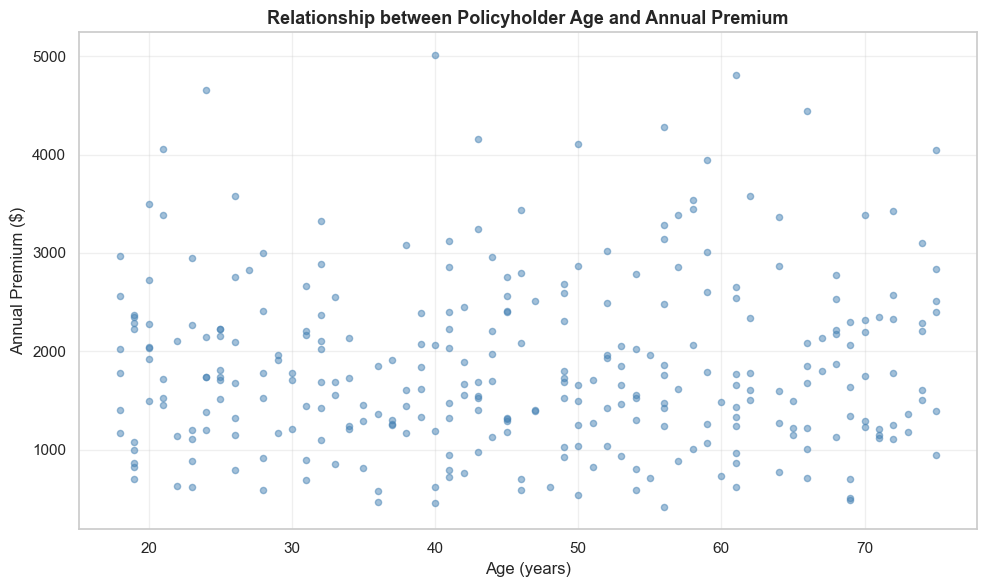

Correlation between age and premium: 0.033


In [ ]:
# Plot 1: Scatter plot - Age vs. Premium
df.plot(kind='scatter', x='age', y='annual_premium', alpha=0.5, color='steelblue')

plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Annual Premium ($)', fontsize=12)
plt.title('Relationship between Policyholder Age and Annual Premium', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlation between age and premium:", df['age'].corr(df['annual_premium']).round(3))

### 3.2 Bar Charts

Bar charts compare categorical data. Common applications:
- Average premium by region
- Claim frequency by vehicle type
- Policyholder counts by gender

```python
df.groupby('region')['annual_premium'].mean().plot(kind='bar')
```

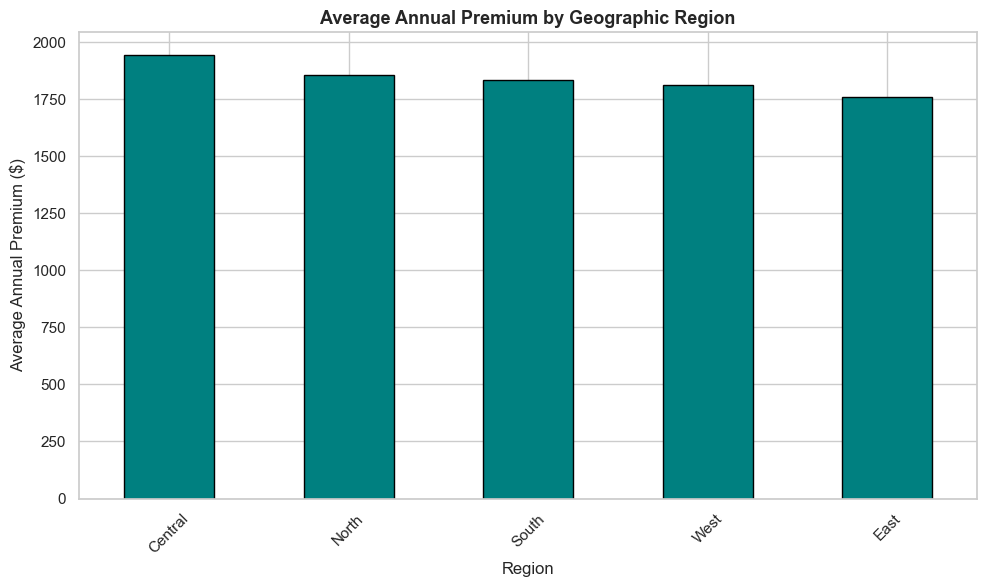

In [ ]:
# Plot 2: Bar chart - Average Premium by Region
avg_premium_region = df.groupby('region')['annual_premium'].mean().sort_values(ascending=False)
avg_premium_region.plot(kind='bar', color='teal', edgecolor='black')

plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Annual Premium ($)', fontsize=12)
plt.title('Average Annual Premium by Geographic Region', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Histograms

Histograms show the distribution of a continuous variable:
- Premium distributions (are they normally distributed?)
- Claim amounts (are they skewed?)
- Age distribution of portfolio

```python
df['annual_premium'].plot(kind='hist', bins=30, edgecolor='black')
```

### Key Visualization Principles
1. **Label axes clearly** with units
2. **Use informative titles** that state what is being shown
3. **Choose appropriate plot types** for your data
4. **Consider color and transparency** for clarity
5. **Add legends** when multiple series are shown

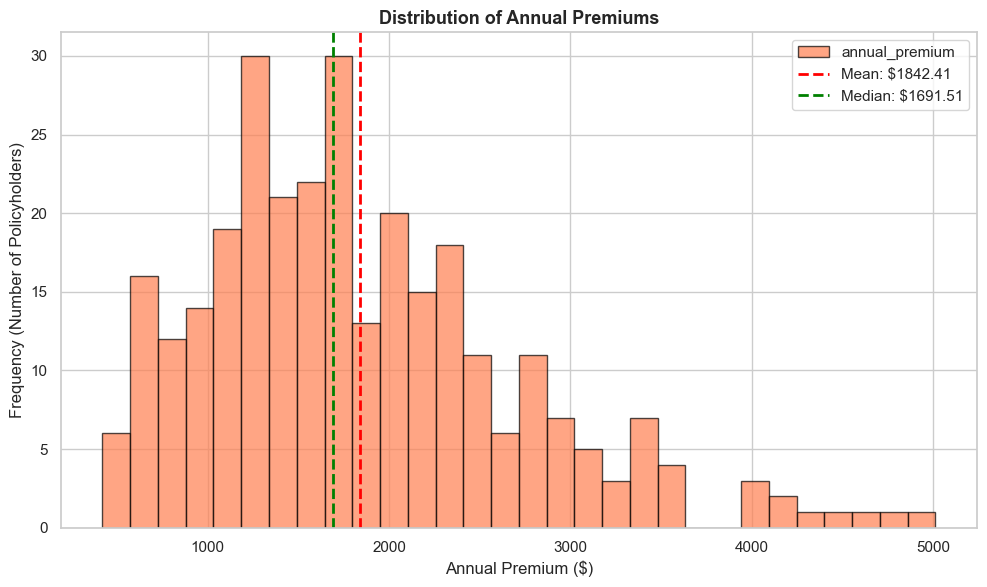

Mean Premium: $1842.41
Median Premium: $1691.51
Std Dev: $869.44


In [ ]:
# Plot 3: Histogram - Distribution of Premium Amounts
df['annual_premium'].plot(kind='hist', bins=30, color='coral', edgecolor='black', alpha=0.7)

plt.xlabel('Annual Premium ($)', fontsize=12)
plt.ylabel('Frequency (Number of Policyholders)', fontsize=12)
plt.title('Distribution of Annual Premiums', fontsize=13, fontweight='bold')
plt.axvline(df['annual_premium'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["annual_premium"].mean():.2f}')
plt.axvline(df['annual_premium'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["annual_premium"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean Premium: ${df['annual_premium'].mean():.2f}")
print(f"Median Premium: ${df['annual_premium'].median():.2f}")
print(f"Std Dev: ${df['annual_premium'].std():.2f}")

### 3.4 *Reading Exercise: Creating Pandas Visualizations*

Read and understand how the visualizations for the following questions are created:

1. **How does claim amount vary by vehicle type?** (Bar chart)
2. **What is the distribution of claims count?** (Histogram)
3. **Is there a relationship between age and claims count?** (Scatter plot)

**Instructions:**
- Vary the code to create alternative visualizations
- Modify titles, labels, and legends


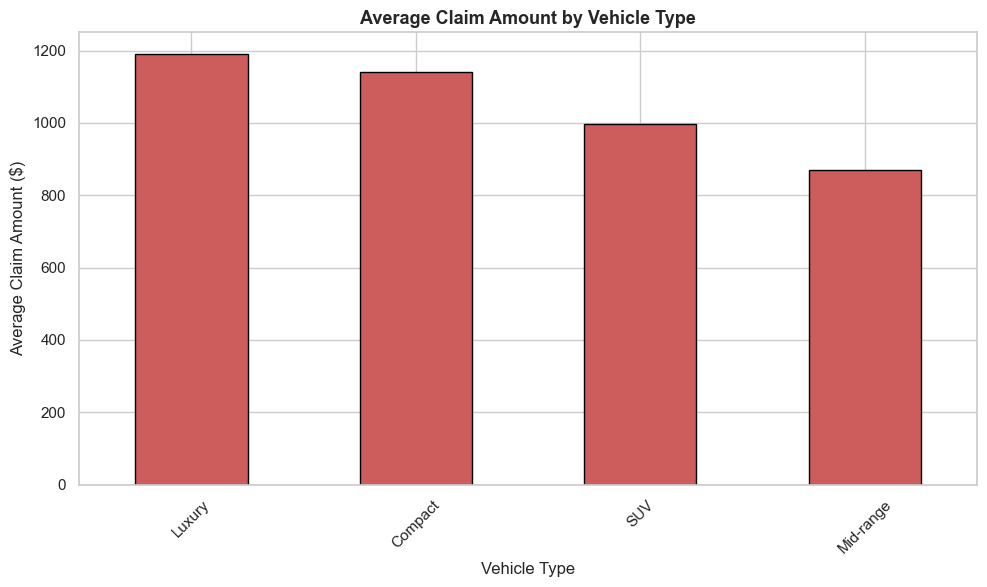

In [ ]:
# Task 1: Bar chart - Average Claim Amount by Vehicle Type
avg_claim_vehicle = df.groupby('vehicle_type')['claim_amount'].mean().sort_values(ascending=False)
avg_claim_vehicle.plot(kind='bar', color='indianred', edgecolor='black')

plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Average Claim Amount ($)', fontsize=12)
plt.title('Average Claim Amount by Vehicle Type', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

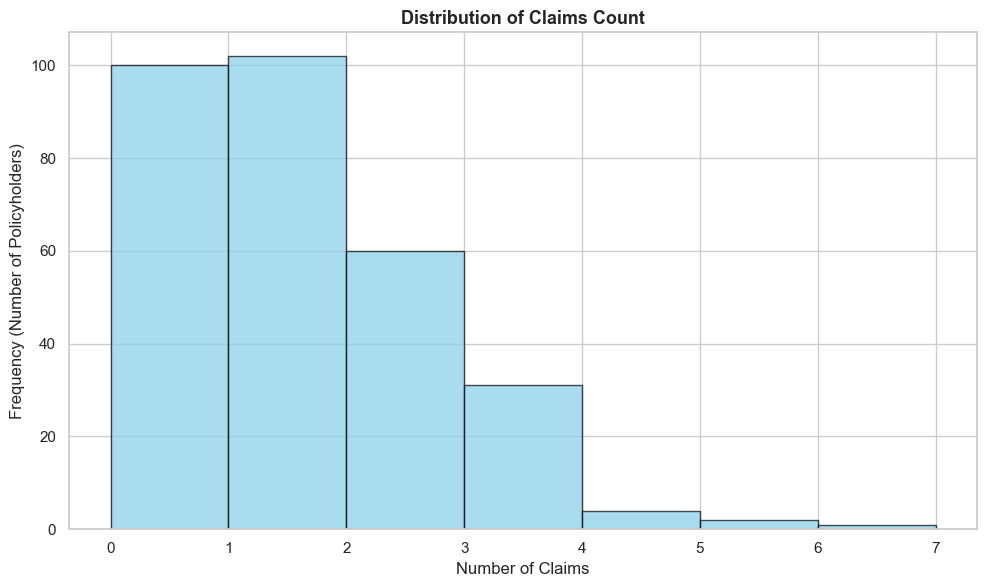

Average claims per policyholder: 1.16
Max claims: 6


In [ ]:
# Task 2: Histogram - Distribution of Claims Count
df['claims_count'].plot(kind='hist', bins=range(0, int(df['claims_count'].max())+2), color='skyblue', edgecolor='black', alpha=0.7)
#df['claims_count'].plot(kind='hist', bins=(int(df['claims_count'].max())+1), color='skyblue', edgecolor='black', alpha=0.7)

# Tough question: Why "+2" in the bins range above? Try the line which is commented out and see what happens.

plt.xlabel('Number of Claims', fontsize=12)
plt.ylabel('Frequency (Number of Policyholders)', fontsize=12)
plt.title('Distribution of Claims Count', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average claims per policyholder: {df['claims_count'].mean():.2f}")
print(f"Max claims: {df['claims_count'].max()}")

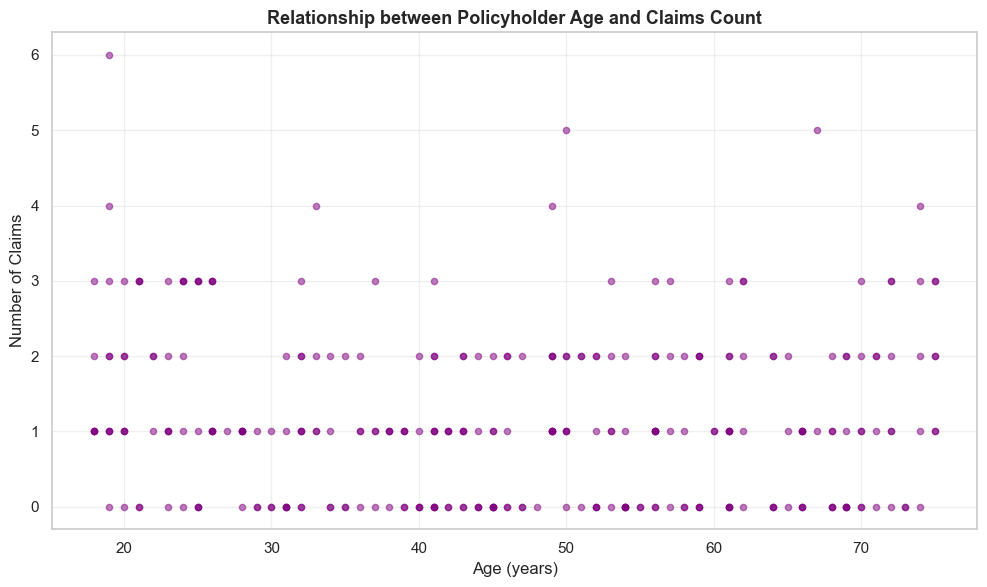

Correlation between age and claims count: -0.076


In [ ]:
# Task 3: Scatter plot - Age vs. Claims Count
df.plot(kind='scatter', x='age', y='claims_count', alpha=0.5, color='purple')

plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Claims', fontsize=12)
plt.title('Relationship between Policyholder Age and Claims Count', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlation between age and claims count:", df['age'].corr(df['claims_count']).round(3))

## Part 4: Advanced Visualization with Seaborn

Seaborn is a statistical visualization library built on Matplotlib. It provides elegant, high-level interfaces for creating complex visualizations with minimal code.

### 4.1 Distribution Visualization

#### Box Plots
Box plots summarize the distribution of a variable by showing:
- **Median** (center line)
- **Interquartile Range** (box: 25th to 75th percentile)
- **Whiskers** (typically extend to 1.5 × IQR)
- **Outliers** (individual points)

Box plots are ideal for comparing distributions across groups, such as premiums by vehicle type.

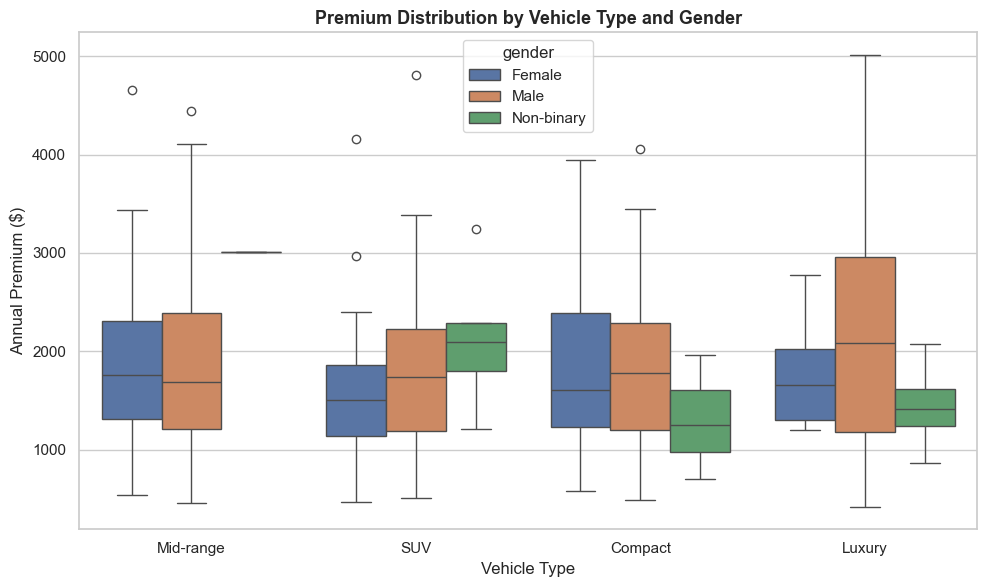

In [ ]:
# Plot 1: Box plot - Premium distribution by Vehicle Type and Gender
sns.boxplot(data=df, x='vehicle_type', y='annual_premium', hue='gender')

plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Annual Premium ($)', fontsize=12)
plt.title('Premium Distribution by Vehicle Type and Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Violin Plots
Violin plots combine a box plot with a kernel density estimate (KDE). They show:
- The full distribution shape
- Density at different values
- More information than box plots but can be harder to interpret at first glance

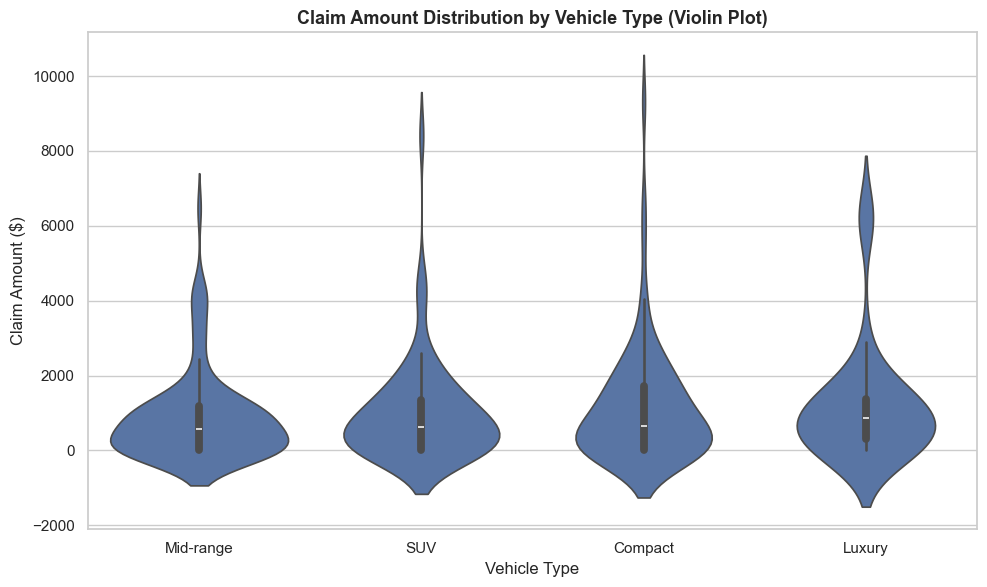

In [ ]:
# Plot 2: Violin plot - Claim Amount distribution by Vehicle Type
sns.violinplot(data=df, x='vehicle_type', y='claim_amount')

plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Claim Amount ($)', fontsize=12)
plt.title('Claim Amount Distribution by Vehicle Type (Violin Plot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Heatmaps

A correlation heatmap shows pairwise relationships between numeric variables as a color-coded matrix. It is a quick way to spot which features are strongly related.

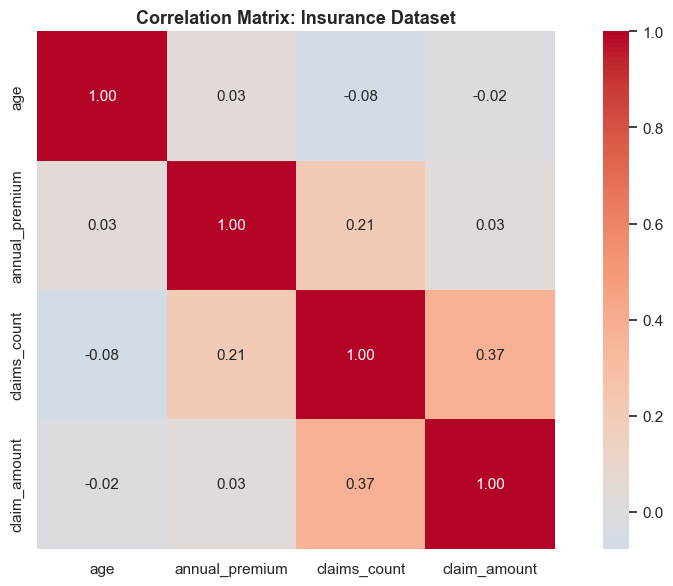

In [ ]:
# Plot 3: Heatmap - Correlation matrix
# Select numeric columns
numeric_df = df[['age', 'annual_premium', 'claims_count', 'claim_amount']]
corr_matrix = numeric_df.corr()

sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)

plt.title('Correlation Matrix: Insurance Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Let's also print the correlation matrix as a table for exact values.

In [ ]:
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                     age  annual_premium  claims_count  claim_amount
age             1.000000        0.033249     -0.076346     -0.021455
annual_premium  0.033249        1.000000      0.205191      0.029816
claims_count   -0.076346        0.205191      1.000000      0.370306
claim_amount   -0.021455        0.029816      0.370306      1.000000


### 4.2 Pairplots

A pairplot shows relationships between multiple variables simultaneously. It creates:
- Scatter plots for every pair of numeric variables
- Histograms on the diagonal

This is powerful for exploratory data analysis and identifying patterns in multivariate data.

### Actuarial Application
In insurance analytics, these visualizations help:
- **Identify outliers** (unusual claims or premiums)
- **Compare groups** (e.g., do different regions have different risk profiles?)
- **Find relationships** (do multiple variables move together?)
- **Communicate findings** to non-technical stakeholders

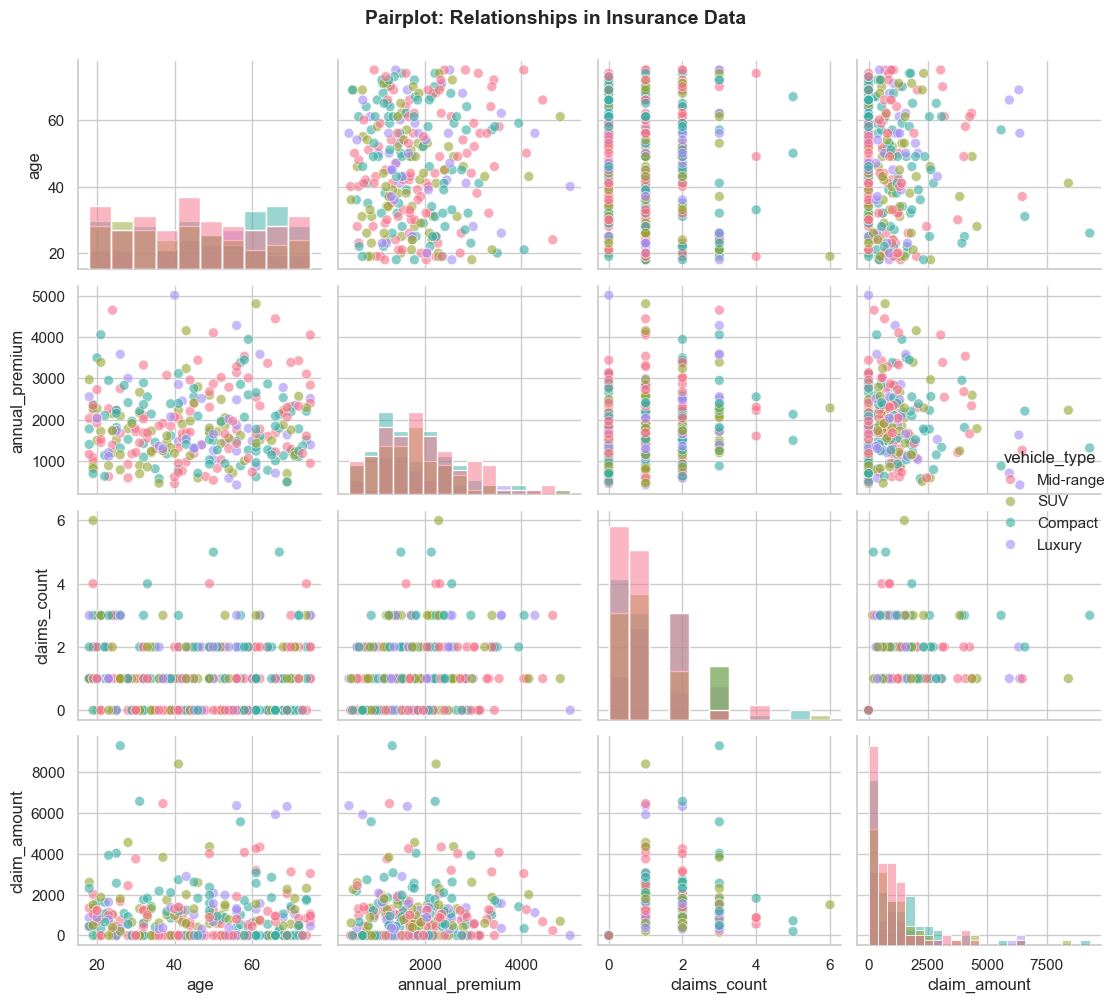

In [ ]:
# Plot 4: Pairplot - Relationships between all numeric variables
# Create a subset with numeric columns and one categorical variable for color
pairplot_df = df[['age', 'annual_premium', 'claims_count', 'claim_amount', 'vehicle_type']].copy()

# For better visualization, create pairplot with a subset (to keep it manageable)
g = sns.pairplot(pairplot_df, hue='vehicle_type', palette='husl', diag_kind='hist',
                 plot_kws={'alpha': 0.6, 's': 50}, height=2.5)

g.fig.suptitle('Pairplot: Relationships in Insurance Data', fontsize=14, fontweight='bold', y=1.00)

plt.tight_layout()
plt.show()


### 4.3 *Reading Exercise: Seaborn Visualization Mastery*

Create advanced visualizations to explore relationships in the insurance data:

1. **Box plot comparison**: Compare premiums across regions and vehicle types
2. **Distribution analysis**: Create a violin plot for claim amounts by gender
3. **Correlation exploration**: Identify which variables move together most strongly

**Instructions:**
- Use Seaborn functions for elegant, informative visualizations
- Add clear titles and labels
- Discuss what patterns you observe and their actuarial significance


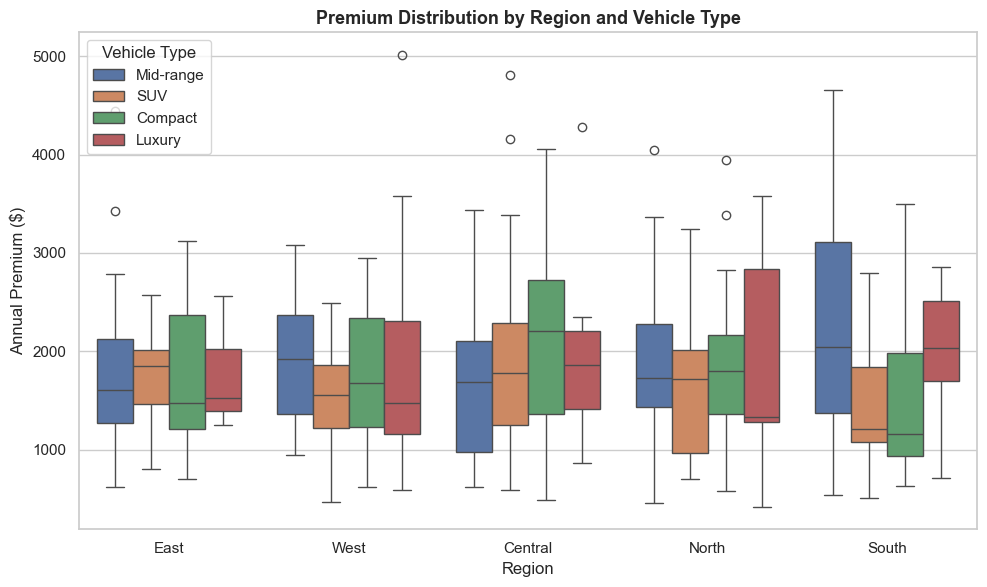

In [ ]:
# Task 1: Box plot - Premium by Region and Vehicle Type
sns.boxplot(data=df, x='region', y='annual_premium', hue='vehicle_type')

plt.xlabel('Region', fontsize=12)
plt.ylabel('Annual Premium ($)', fontsize=12)
plt.title('Premium Distribution by Region and Vehicle Type', fontsize=13, fontweight='bold')
plt.legend(title='Vehicle Type', loc='upper left')
plt.tight_layout()
plt.show()

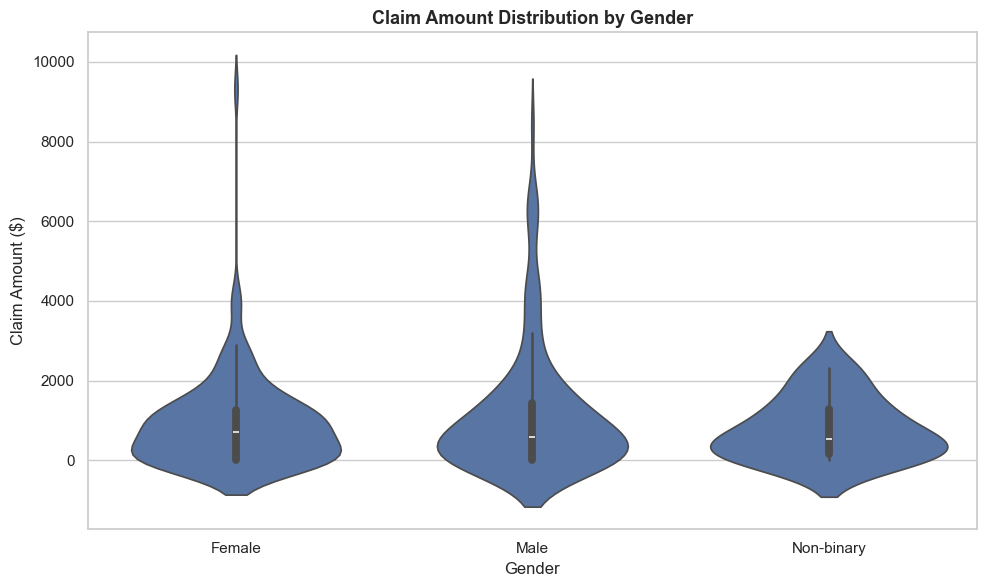

Average claim amount by gender:
                   mean  median          std  count
gender                                             
Female       906.053037  694.98  1153.848827    135
Male        1145.824145  582.11  1594.549594    152
Non-binary   775.090000  529.80   766.766807     13


In [ ]:
# Task 2: Violin plot - Claim Amount by Gender
sns.violinplot(data=df, x='gender', y='claim_amount')

plt.xlabel('Gender', fontsize=12)
plt.ylabel('Claim Amount ($)', fontsize=12)
plt.title('Claim Amount Distribution by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics by gender
print("Average claim amount by gender:")
print(df.groupby('gender')['claim_amount'].agg(['mean', 'median', 'std', 'count']))

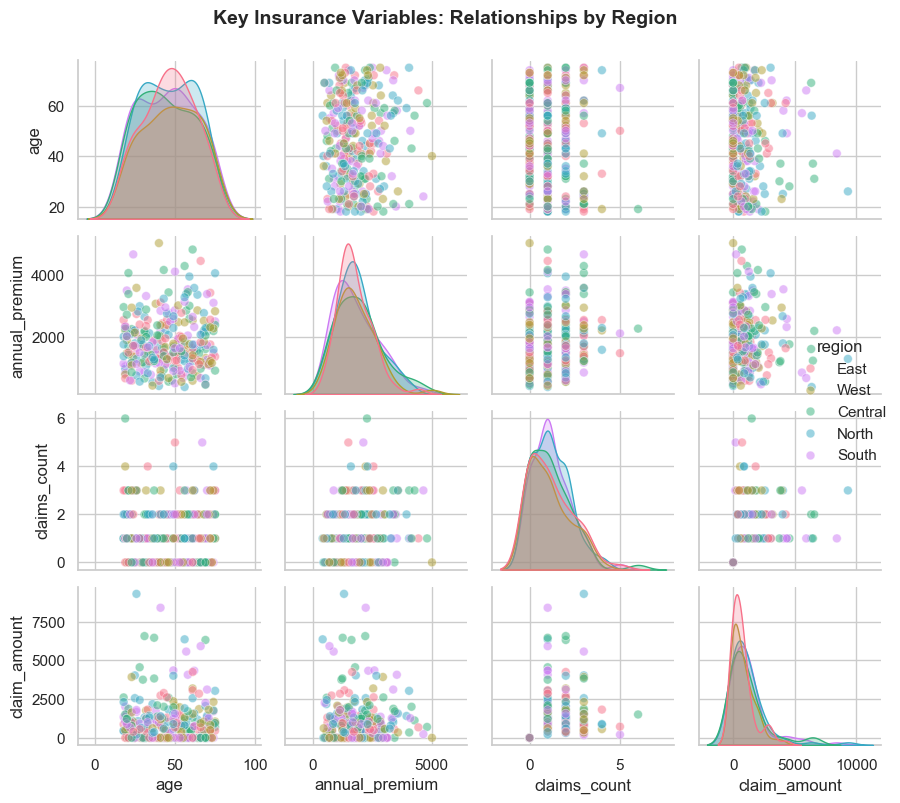

In [ ]:
# Task 3: Create a focused pairplot with subset of key variables
# Select key variables for analysis
key_vars = df[['age', 'annual_premium', 'claims_count', 'claim_amount', 'region']].copy()

# Create pairplot with region coloring
g = sns.pairplot(data=key_vars, hue='region', palette='husl', diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 40}, height=2)

g.fig.suptitle('Key Insurance Variables: Relationships by Region', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## Summary and Key Takeaways

Congratulations! You have now completed a comprehensive introduction to data visualization for insurance analytics using Python.

### What You Have Learned

1. **NumPy Fundamentals**
   - Create and manipulate arrays efficiently
   - Apply vectorized operations to large datasets
   - Work with multi-dimensional data

2. **Pandas Data Manipulation**
   - Load and explore data using DataFrames and Series
   - Perform grouping and aggregation operations
   - Analyze insurance data systematically

3. **Visualization with Pandas**
   - Create scatter plots to explore relationships
   - Use bar charts for categorical comparisons
   - Build histograms to understand distributions

4. **Advanced Visualization with Seaborn**
   - Leverage box plots and violin plots for distribution analysis
   - Build pairplots to investigate multivariate relationships
   - Create heatmaps to visualize correlations

### Resources

- [NumPy Documentation](https://numpy.org/doc/)
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Matplotlib User Guide](https://matplotlib.org/stable/users/index.html)
- [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html)

---

**Thank you for participating in this workshop!** We hope you now feel confident using Python for data visualization and analysis in your actuarial work.
